# Canlı Sistem Değerlendirmesi — `evaluate_live.ipynb`

Bu defter, **gerçek testbed başarımını** ölçer (CICIoT2023 test metriği DEĞİL).
İki girdiyi eşleştirir:

1. `ground_truth.csv` — saldırgan VM'deki `attack-runner.sh` çıktısı (her saldırının
   başlangıç/bitiş zamanı + MITRE ID).
2. `detections.jsonl` — sensörün (Pi/host) ürettiği kalıcı log (`logs/detections.jsonl`).

Çıktı: saldırı-bazlı **recall**, iyi huylu trafikte **false positive**, **gecikme** (Pi
çıkarım süresi) ve tez için grafikler.

> Varsayım: saldırgan ve sensör saatleri aynı saat diliminde ve NTP ile senkron.
> Eşleştirme zaman penceresine (±`TOL_SEC`) dayanır.

In [2]:
import json, math
from datetime import datetime, timedelta
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ayarlar
GROUND_TRUTH = "ground_truth.csv"      # saldirgan VM'den
DETECTIONS   = "detections.jsonl"      # sensorden (logs/detections.jsonl)
TOL_SEC      = 5                       # pencere kenari toleransi (saat kaymasi payi)
ANOMALY_LABEL = "ANOMALY" 

## 1. Verileri yükle

In [3]:
gt = pd.read_csv(GROUND_TRUTH)
gt["start"] = pd.to_datetime(gt["start_iso"])
gt["end"]   = pd.to_datetime(gt["end_iso"])
print(f"Ground truth pencere sayisi: {len(gt)}")
gt[["start_iso", "end_iso", "label", "attack_type", "mitre"]]

Ground truth pencere sayisi: 7


,start_iso,end_iso,label,attack_type,mitre
0,2026-06-15T12:02:55,2026-06-15T12:03:16,BENIGN,BENIGN,-
1,2026-06-15T12:03:24,2026-06-15T12:03:24,ANOMALY,PortScan,T1046
2,2026-06-15T12:03:32,2026-06-15T12:03:52,ANOMALY,SYN_Flood,T1498
3,2026-06-15T12:04:00,2026-06-15T12:04:20,ANOMALY,DoS_Flood,T1498
4,2026-06-15T12:04:28,2026-06-15T12:04:48,ANOMALY,DoS_Flood,T1498
5,2026-06-15T12:04:56,2026-06-15T12:05:03,ANOMALY,BruteForce,T1110
6,2026-06-15T12:05:12,2026-06-15T12:05:32,BENIGN,BENIGN,-


In [4]:
dets = []
with open(DETECTIONS, encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        try:
            dets.append(json.loads(line))
        except Exception:
            pass
det = pd.DataFrame(dets)
if "ts_iso" in det.columns:
    det["ts"] = pd.to_datetime(det["ts_iso"])
else:
    today = datetime.now().strftime("%Y-%m-%d")
    det["ts"] = pd.to_datetime(today + " " + det["timestamp"].astype(str))
for c in ["threat_score", "inference_ms"]:
    if c in det.columns:
        det[c] = pd.to_numeric(det[c], errors="coerce")
n_anom = int((det.get("label") == ANOMALY_LABEL).sum()) if len(det) else 0
print(f"Toplam tespit kaydi: {len(det)}  |  ANOMALY: {n_anom}")
det[["ts", "label", "attack_type", "method", "threat_score"]].head()

Toplam tespit kaydi: 14337  |  ANOMALY: 14337


,ts,label,attack_type,method,threat_score
0,2026-06-15 15:03:01.878,ANOMALY,ML_Detected,xgboost,99
1,2026-06-15 15:03:02.884,ANOMALY,ML_Detected,xgboost,99
2,2026-06-15 15:03:04.894,ANOMALY,ML_Detected,xgboost,99
3,2026-06-15 15:03:05.898,ANOMALY,ML_Detected,xgboost,99
4,2026-06-15 15:03:07.903,ANOMALY,ML_Detected,xgboost,99


## 1.5. Otomatik saat-ofseti hizalama

Pi (tespit) ile saldırgan VM (ground truth) saatleri farklı saat dilimi/drift yüzünden kayık olabilir. Tespit yoğunluğunu saldırı pencerelerine hizalayarak sabit ofseti otomatik buluruz — saat senkronu gerekmez.

In [5]:
AUTO_OFFSET = True   # Pi/saldırgan saat farkını otomatik düzelt
OFFSET_SEC = 0
if AUTO_OFFSET and len(det) and (gt['label'] == ANOMALY_LABEL).any():
    atk_gt = gt[gt['label'] == ANOMALY_LABEL]
    det_s  = det['ts'].apply(lambda x: x.timestamp()).to_numpy()
    starts = atk_gt['start'].apply(lambda x: x.timestamp()).to_numpy()
    ends   = atk_gt['end'].apply(lambda x: x.timestamp()).to_numpy()
    coarse = float(np.median(det_s) - np.median((starts + ends) / 2))
    best, best_cnt = coarse, -1
    for delta in range(int(coarse) - 120, int(coarse) + 121):
        shifted = det_s - delta
        cnt = int(sum(((shifted >= s - TOL_SEC) & (shifted <= e + TOL_SEC)).sum()
                      for s, e in zip(starts, ends)))
        if cnt > best_cnt:
            best_cnt, best = cnt, delta
    OFFSET_SEC = best
    det['ts'] = det['ts'] - pd.to_timedelta(OFFSET_SEC, unit='s')
    print(f'Otomatik saat ofseti uygulandi: {OFFSET_SEC} sn '
          f'(kaba tahmin {coarse:.0f}). Saldiri penceresine dusen tespit: {best_cnt}')
    print('NOT: Ofset cok buyukse (saat/TZ farki) bu normaldir; onemli olan hizalama.')
else:
    print('Otomatik ofset atlandi.')

Otomatik saat ofseti uygulandi: 10744 sn (kaba tahmin 10782). Saldiri penceresine dusen tespit: 16976
NOT: Ofset cok buyukse (saat/TZ farki) bu normaldir; onemli olan hizalama.


## 2. Pencere-bazlı eşleştirme (recall & doğru-tür)

Her **saldırı** penceresi için: pencerede (±tolerans) en az bir `ANOMALY` tespiti
varsa **yakalandı (TP)**; yoksa **kaçırıldı (FN)**. Tespit edilen türün beklenen
türle eşleşmesi (kural katmanı için) ayrıca raporlanır.

In [6]:
def dets_in_window(row, only_anomaly=True):
    lo = row["start"] - timedelta(seconds=TOL_SEC)
    hi = row["end"]   + timedelta(seconds=TOL_SEC)
    sub = det[(det["ts"] >= lo) & (det["ts"] <= hi)]
    if only_anomaly and "label" in sub.columns:
        sub = sub[sub["label"] == ANOMALY_LABEL]
    return sub

rows = []
for _, r in gt.iterrows():
    sub = dets_in_window(r)
    n = len(sub)
    n_correct = int((sub.get("attack_type") == r["attack_type"]).sum()) if n else 0
    detected = n > 0
    if r["label"] == ANOMALY_LABEL:
        outcome = "TP" if detected else "FN"
    else:
        outcome = "FP" if detected else "TN"
    rows.append({
        "attack_type": r["attack_type"], "mitre": r["mitre"], "label": r["label"],
        "pencere": f'{r["start_iso"][11:]}-{r["end_iso"][11:]}',
        "anomaly_tespit": n, "dogru_tur": n_correct, "sonuc": outcome,
    })
res = pd.DataFrame(rows)
res

,attack_type,mitre,label,pencere,anomaly_tespit,dogru_tur,sonuc
0,BENIGN,-,BENIGN,12:02:55-12:03:16,0,0,TN
1,PortScan,T1046,ANOMALY,12:03:24-12:03:24,0,0,FN
2,SYN_Flood,T1498,ANOMALY,12:03:32-12:03:52,0,0,FN
3,DoS_Flood,T1498,ANOMALY,12:04:00-12:04:20,9,0,TP
4,DoS_Flood,T1498,ANOMALY,12:04:28-12:04:48,11026,582,TP
5,BruteForce,T1110,ANOMALY,12:04:56-12:05:03,5941,0,TP
6,BENIGN,-,BENIGN,12:05:12-12:05:32,0,0,TN


## 3. Özet metrikler (pencere-bazlı)

In [7]:
atk = res[res["label"] == ANOMALY_LABEL]
ben = res[res["label"] != ANOMALY_LABEL]

TP = int((atk["sonuc"] == "TP").sum())
FN = int((atk["sonuc"] == "FN").sum())
FP = int((ben["sonuc"] == "FP").sum())
TN = int((ben["sonuc"] == "TN").sum())

recall = TP / (TP + FN) if (TP + FN) else float("nan")

fp_detections = 0
for _, r in gt[gt["label"] != ANOMALY_LABEL].iterrows():
    fp_detections += len(dets_in_window(r))
benign_secs = float((gt[gt["label"] != ANOMALY_LABEL]["end"] -
                     gt[gt["label"] != ANOMALY_LABEL]["start"]).dt.total_seconds().sum()) or 1.0

print(f"Saldiri penceresi: {TP+FN}  | Yakalanan (TP): {TP}  | Kacan (FN): {FN}")
print(f"Iyi huylu pencere: {FP+TN} | Yanlis alarmli (FP): {FP}  | Temiz (TN): {TN}")
print(f"\nRECALL (saldiri yakalama)       : {recall:.3f}")
print(f"Iyi huylu pencerede yanlis alarm: {fp_detections} adet "
      f"({fp_detections/benign_secs*60:.1f} alarm/dk)")

Saldiri penceresi: 5  | Yakalanan (TP): 3  | Kacan (FN): 2
Iyi huylu pencere: 2 | Yanlis alarmli (FP): 0  | Temiz (TN): 2

RECALL (saldiri yakalama)       : 0.600
Iyi huylu pencerede yanlis alarm: 0 adet (0.0 alarm/dk)


## 4. Pi çıkarım gecikmesi (XGBoost)

In [8]:
if "inference_ms" in det.columns and "method" in det.columns:
    xgb = det[det["method"] == "xgboost"]["inference_ms"].dropna()
    if len(xgb):
        print(f"XGBoost akis basina cikarim (ms): ort={xgb.mean():.2f}  "
              f"medyan={xgb.median():.2f}  p95={xgb.quantile(0.95):.2f}  "
              f"max={xgb.max():.2f}  (n={len(xgb)})")
    else:
        print("XGBoost tespiti yok (model yuklu mu / CANLI modda mi?).")
else:
    print("inference_ms/method alani yok.")

XGBoost akis basina cikarim (ms): ort=4.81  medyan=3.64  p95=12.50  max=22.16  (n=26)


## 5. Grafikler (tez için)

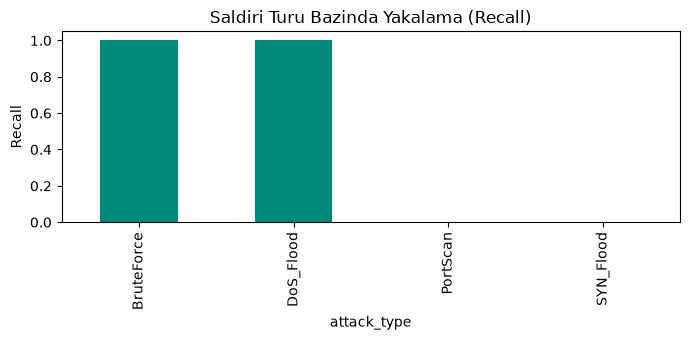

In [9]:
if len(atk):
    g = atk.groupby("attack_type")["sonuc"].apply(lambda s: (s == "TP").mean())
    ax = g.plot(kind="bar", color="#00897b", figsize=(7, 3.5))
    ax.set_ylabel("Recall"); ax.set_ylim(0, 1.05)
    ax.set_title("Saldiri Turu Bazinda Yakalama (Recall)")
    plt.tight_layout(); plt.savefig("eval_recall_by_attack.png", dpi=150); plt.show()

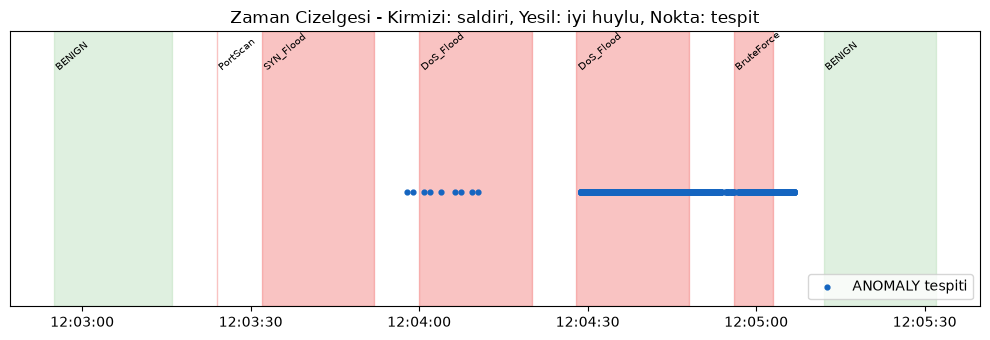

In [10]:
fig, ax = plt.subplots(figsize=(10, 3.5))
for _, r in gt.iterrows():
    color = "#ef5350" if r["label"] == ANOMALY_LABEL else "#a5d6a7"
    ax.axvspan(r["start"], r["end"], color=color, alpha=0.35)
    ax.text(r["start"], 1.02, r["attack_type"], rotation=40, fontsize=7, va="bottom")
an = det[det.get("label") == ANOMALY_LABEL]
ax.scatter(an["ts"], [0.5] * len(an), s=12, color="#1565c0", label="ANOMALY tespiti", zorder=3)
ax.set_yticks([]); ax.set_ylim(0, 1.2); ax.legend(loc="lower right")
ax.set_title("Zaman Cizelgesi - Kirmizi: saldiri, Yesil: iyi huylu, Nokta: tespit")
plt.tight_layout(); plt.savefig("eval_timeline.png", dpi=150); plt.show()

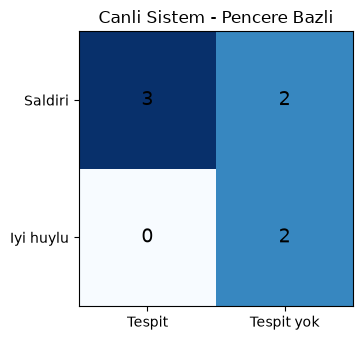

In [11]:
cm = np.array([[TP, FN], [FP, TN]])
fig, ax = plt.subplots(figsize=(4, 3.5))
ax.imshow(cm, cmap="Blues")
for (i, j), v in np.ndenumerate(cm):
    ax.text(j, i, str(v), ha="center", va="center", fontsize=14)
ax.set_xticks([0, 1]); ax.set_xticklabels(["Tespit", "Tespit yok"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["Saldiri", "Iyi huylu"])
ax.set_title("Canli Sistem - Pencere Bazli")
plt.tight_layout(); plt.savefig("eval_confusion.png", dpi=150); plt.show()

## 6. Notlar / Sınırlar (dürüst değerlendirme için)

- Bu metrikler **canlı testbed** başarımıdır; CICIoT2023 test metriğiyle karıştırılmamalıdır.
- `Slowloris` gibi yavaş saldırılar kural katmanı tarafından **kaçırılabilir** (FN) —
  beklenen bir sınırdır, Discussion'da dürüstçe raporlanmalıdır.
- XGBoost canlı tespitleri yalnızca model yeniden eğitilip (`models/` güncel) ve sensör
  **CANLI** (DEMO kapalı) çalıştığında oluşur.
- Eşleştirme zaman penceresine dayanır; saat senkronu (NTP) doğruluğu etkiler.